In [1]:
import os
import sys

if '__file__' in globals():
    current_dir = os.path.dirname(os.path.abspath(__file__))
else:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [7]:
import pandas as pd
import os
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from dataset import StrictMonotonicCKF


# --- 1. FIT GLOBAL PCA ---
def fit_global_pca(file_list, scenarios, artifact_dir, n_components=None, export_format='csv'):
    fitted = {}

    for scenario_name, cols in scenarios.items():
        print(f"\n--- Fitting global PCA for [{scenario_name}] ---")
        all_features = []

        for file_path in file_list:
            if not os.path.exists(file_path):
                continue
            df = pd.read_csv(file_path)
            df = df.interpolate(method='linear').ffill().bfill()
            available_cols = [c for c in cols if c in df.columns]
            if not available_cols:
                continue
            all_features.append(df[available_cols].values)

        if not all_features:
            print(f"  Tidak ada data untuk scenario [{scenario_name}]")
            continue

        combined   = np.vstack(all_features)
        n_features = combined.shape[1]

        scaler = StandardScaler()
        scaled = scaler.fit_transform(combined)

        pca = PCA(n_components=n_components)
        pca.fit(scaled)

        n_pcs     = pca.n_components_
        pc_labels = [f"PC{i+1}" for i in range(n_pcs)]

        # --- Eigenvalues & Variance ---
        eigen_df = pd.DataFrame({
            'PC':                pc_labels,
            'Eigenvalue':        pca.explained_variance_,
            'ExplainedVar_Pct':  pca.explained_variance_ratio_ * 100,
            'CumulativeVar_Pct': np.cumsum(pca.explained_variance_ratio_) * 100,
        })

        # --- Eigenvectors (loadings) ---
        loading_df = pd.DataFrame(
            pca.components_.T,
            index=cols[:n_features],
            columns=pc_labels
        )

        # --- Export ---
        if export_format == 'csv':
            eigen_path   = os.path.join(artifact_dir, f'pca_eigenvalues_{scenario_name}.csv')
            loading_path = os.path.join(artifact_dir, f'pca_loadings_{scenario_name}.csv')
            eigen_df.to_csv(eigen_path, index=False)
            loading_df.to_csv(loading_path)
            print(f"  Saved: {eigen_path}")
            print(f"  Saved: {loading_path}")

        elif export_format == 'txt':
            report_path = os.path.join(artifact_dir, f'pca_report_{scenario_name}.txt')
            with open(report_path, 'w') as f:
                f.write(f"=== PCA Report: {scenario_name} ===\n\n")
                f.write("-- Eigenvalues & Variance --\n")
                f.write(eigen_df.to_string(index=False))
                f.write("\n\n-- Eigenvectors (Loadings) --\n")
                f.write(loading_df.to_string())
                f.write("\n")
            print(f"  Saved: {report_path}")

        # Fit ulang PC1 saja untuk transform & simpan artifact
        pca_pc1 = PCA(n_components=1)
        pca_pc1.fit(scaled)
        joblib.dump(scaler,  os.path.join(artifact_dir, f'scaler_std_{scenario_name}.pkl'))
        joblib.dump(pca_pc1, os.path.join(artifact_dir, f'pca_{scenario_name}.pkl'))
        print(f"  Saved: scaler_std_{scenario_name}.pkl | pca_{scenario_name}.pkl")

        fitted[scenario_name] = {'scaler': scaler, 'pca': pca_pc1, 'cols': cols}

    return fitted


# --- 2. TRANSFORM TIAP FILE MENGGUNAKAN GLOBAL PCA ---
def transform_files(file_list, fitted, output_dir):
    output_files = []

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"File tidak ditemukan, dilewati: {file_path}")
            continue

        print(f"\nTransforming: {file_path}")
        df_raw    = pd.read_csv(file_path)
        df_filled = df_raw.interpolate(method='linear').ffill().bfill()
        pca_results = pd.DataFrame(index=df_raw.index)

        for scenario_name, artifacts in fitted.items():
            scaler = artifacts['scaler']
            pca    = artifacts['pca']
            cols   = artifacts['cols']

            available_cols = [c for c in cols if c in df_filled.columns]
            if not available_cols:
                continue

            features    = df_filled[available_cols].values
            scaled      = scaler.transform(features)
            pc1_raw     = pca.transform(scaled).flatten()

            pca_results[f"PC1_Raw_{scenario_name}"] = pc1_raw

            ckf = StrictMonotonicCKF(initial_value=pc1_raw[0], meas_var=15.0)
            pc1_filtered = np.array([ckf.process(v) for v in pc1_raw])
            pca_results[f"PC1_{scenario_name}"] = pc1_filtered

        file_name = os.path.basename(file_path)
        out_path  = os.path.join(output_dir, f"PCA_Results_{file_name}")
        pca_results.to_csv(out_path, index=False)
        output_files.append(out_path)
        print(f"  Saved: {out_path}")

    return output_files


# --- 3. FIT & TERAPKAN GLOBAL MINMAX ---
def fit_and_apply_global_minmax(output_files, scenarios_to_normalize, artifact_dir):
    scalers = {}

    for scenario in scenarios_to_normalize:
        col = f"PC1_{scenario}"
        print(f"\n--- Global MinMax untuk [{scenario}] ---")
        all_values  = []
        valid_files = []

        for f in output_files:
            df = pd.read_csv(f)
            if col in df.columns:
                all_values.append(df[col].values)
                valid_files.append(f)

        if not all_values:
            print(f"  Kolom {col} tidak ditemukan.")
            continue

        combined = np.concatenate(all_values).reshape(-1, 1)
        minmax   = MinMaxScaler(feature_range=(0, 1))
        minmax.fit(combined)

        for f in valid_files:
            df = pd.read_csv(f)
            df[col] = minmax.transform(df[col].values.reshape(-1, 1))
            df.to_csv(f, index=False)
            print(f"  Normalized & overwritten: {f}")

        minmax_path = os.path.join(artifact_dir, f'scaler_minmax_{scenario}.pkl')
        joblib.dump(minmax, minmax_path)
        print(f"  Saved: {minmax_path}")
        scalers[scenario] = minmax

    return scalers


# --- 4. MAIN ---
#data_dir     = r"../Preprocess/Imputed Data"
#output_dir   = r"PCA Result/Outliered Data"
#artifact_dir = r"PCA Result/Artifacts Outliered"

data_dir     = r"../Preprocess/Clean Data"
output_dir   = r"PCA Result/No-Outlier Data"
artifact_dir = r"PCA Result/Artifacts No-Outlier"

os.makedirs(output_dir,   exist_ok=True)
os.makedirs(artifact_dir, exist_ok=True)

if not os.path.exists(data_dir):
    print(f"Direktori tidak ditemukan: {data_dir}")
else:
    cyl_cols     = [f'Exh Cyl #{i} Temp' for i in range(1, 6)]
    support_cols = ['Exh Right Temp', 'Exh Left Temp', 'JW Temp']

    scenarios = {
        'Combustion': cyl_cols,
        'Systemic':   support_cols,
        'Global':     cyl_cols + support_cols,
    }

    input_files = [
        os.path.join(data_dir, f'run_to_failure{i}.csv')
        for i in range(1, 6)
    ]

    # Step 1 — fit PCA secara global
    fitted_artifacts = fit_global_pca(
        input_files, scenarios, artifact_dir,
        n_components=None, export_format='csv'
    )

    # Step 2 — transform tiap file & simpan CSV
    output_files = transform_files(input_files, fitted_artifacts, output_dir)

    # Step 3 — fit MinMax secara global & normalisasi
    if output_files:
        fit_and_apply_global_minmax(
            output_files,
            scenarios_to_normalize=['Combustion', 'Systemic', 'Global'],
            artifact_dir=artifact_dir
        )

    print("\n--- Proses Selesai ---")
    print(f"\nArtifact tersimpan di: {artifact_dir}")
    for s in scenarios:
        print(f"  scaler_std_{s}.pkl        — StandardScaler")
        print(f"  pca_{s}.pkl               — PCA model (PC1)")
        print(f"  scaler_minmax_{s}.pkl     — MinMaxScaler (0–1)")
        print(f"  pca_eigenvalues_{s}.csv   — Eigenvalue & Variance")
        print(f"  pca_loadings_{s}.csv      — Eigenvectors")


--- Fitting global PCA for [Combustion] ---
  Saved: PCA Result/Artifacts No-Outlier\pca_eigenvalues_Combustion.csv
  Saved: PCA Result/Artifacts No-Outlier\pca_loadings_Combustion.csv
  Saved: scaler_std_Combustion.pkl | pca_Combustion.pkl

--- Fitting global PCA for [Systemic] ---
  Saved: PCA Result/Artifacts No-Outlier\pca_eigenvalues_Systemic.csv
  Saved: PCA Result/Artifacts No-Outlier\pca_loadings_Systemic.csv
  Saved: scaler_std_Systemic.pkl | pca_Systemic.pkl

--- Fitting global PCA for [Global] ---
  Saved: PCA Result/Artifacts No-Outlier\pca_eigenvalues_Global.csv
  Saved: PCA Result/Artifacts No-Outlier\pca_loadings_Global.csv
  Saved: scaler_std_Global.pkl | pca_Global.pkl

Transforming: ../Preprocess/Clean Data\run_to_failure1.csv
  Saved: PCA Result/No-Outlier Data\PCA_Results_run_to_failure1.csv

Transforming: ../Preprocess/Clean Data\run_to_failure2.csv
  Saved: PCA Result/No-Outlier Data\PCA_Results_run_to_failure2.csv

Transforming: ../Preprocess/Clean Data\run_to_f

In [12]:
import pandas as pd
import os
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from dataset import StrictMonotonicCKF


# --- OPERATION FUNC: PCA + CKF ---
def pca_transformer(df, fitted, meas_var=15.0, **kwargs):
    df_filled   = df.interpolate(method='linear').ffill().bfill()
    pca_results = pd.DataFrame(index=df.index)

    for scenario_name, artifacts in fitted.items():
        scaler = artifacts['scaler']
        pca    = artifacts['pca']
        cols   = artifacts['cols']

        available_cols = [c for c in cols if c in df_filled.columns]
        if not available_cols:
            print(f"  [{scenario_name}] kolom tidak ditemukan, skip.")
            continue

        features = df_filled[available_cols].values
        scaled   = scaler.transform(features)
        pc1_raw  = pca.transform(scaled).flatten()

        pca_results[f"PC1_Raw_{scenario_name}"] = pc1_raw

        ckf = StrictMonotonicCKF(initial_value=pc1_raw[0], meas_var=meas_var)
        pc1_filtered = np.array([ckf.process(v) for v in pc1_raw])
        pca_results[f"PC1_{scenario_name}"] = pc1_filtered

    return pca_results


# --- OPERATION FUNC: MinMax ---
def minmax_normalizer(df, scalers, scenarios_to_normalize, **kwargs):
    df_out = df.copy()
    for scenario in scenarios_to_normalize:
        col = f"PC1_{scenario}"
        if col not in df_out.columns:
            print(f"  Kolom {col} tidak ditemukan, skip.")
            continue
        if scenario not in scalers:
            print(f"  Scaler [{scenario}] tidak ada, skip.")
            continue
        df_out[col] = scalers[scenario].transform(df_out[col].values.reshape(-1, 1))
    return df_out


# --- LOAD ARTIFACTS ---
def load_fitted_artifacts(scenarios, artifact_dir):
    fitted = {}
    for scenario_name, cols in scenarios.items():
        scaler_path = os.path.join(artifact_dir, f'scaler_std_{scenario_name}.pkl')
        pca_path    = os.path.join(artifact_dir, f'pca_{scenario_name}.pkl')
        if not os.path.exists(scaler_path) or not os.path.exists(pca_path):
            print(f"  Artifact tidak ditemukan: [{scenario_name}], skip.")
            continue
        fitted[scenario_name] = {
            'scaler': joblib.load(scaler_path),
            'pca':    joblib.load(pca_path),
            'cols':   cols,
        }
        print(f"  Loaded: {scaler_path} | {pca_path}")
    return fitted


def load_minmax_artifacts(scenarios_to_normalize, artifact_dir):
    scalers = {}
    for scenario in scenarios_to_normalize:
        path = os.path.join(artifact_dir, f'scaler_minmax_{scenario}.pkl')
        if not os.path.exists(path):
            print(f"  MinMax artifact tidak ditemukan: {path}")
            continue
        scalers[scenario] = joblib.load(path)
        print(f"  Loaded: {path}")
    return scalers


# ============================================================
# MAIN
# ============================================================
data_dir     = r"../Preprocess/Clean Data"
output_dir   = r"PCA Result/No-Outlier Data"
artifact_dir = r"PCA Result/Artifacts No-Outlier"

os.makedirs(output_dir, exist_ok=True)

cyl_cols     = [f'Exh Cyl #{i} Temp' for i in range(1, 7)]
support_cols = ['Exh Right Temp', 'Exh Left Temp', 'Oil Temp', 'JW Temp']

scenarios = {
    'Combustion': cyl_cols,
    'Systemic':   support_cols,
    'Global':     cyl_cols + support_cols,
}
scenarios_to_normalize = ['Combustion', 'Systemic', 'Global']

new_files = [f'run_to_failure{i}.csv' for i in range(6, 8)]

# Step 1 — Load semua artifact dari disk
print("=== Loading Artifacts ===")
fitted_artifacts = load_fitted_artifacts(scenarios, artifact_dir)
scalers          = load_minmax_artifacts(scenarios_to_normalize, artifact_dir)

# Step 2 — Transform (PCA + CKF)
print("\n=== Transform: PCA + CKF ===")
output_files = []
for file_name in new_files:
    input_path = os.path.join(data_dir, file_name)
    if not os.path.exists(input_path):
        print(f"File tidak ditemukan: {input_path}")
        continue

    print(f"\n--- Processing: {file_name} ---")
    df        = pd.read_csv(input_path)
    df_result = pca_transformer(df, fitted=fitted_artifacts, meas_var=15.0)

    out_path  = os.path.join(output_dir, f"PCA_Results_{file_name}")
    df_result.to_csv(out_path, index=False)
    output_files.append(out_path)
    print(f"  Saved: {out_path}")

# Step 3 — Normalize (MinMax)
print("\n=== Normalize: MinMax ===")
for out_path in output_files:
    df        = pd.read_csv(out_path)
    df_result = minmax_normalizer(df, scalers=scalers, scenarios_to_normalize=scenarios_to_normalize)
    df_result.to_csv(out_path, index=False)
    print(f"  Normalized: {out_path}")

print("\n--- Selesai ---")

=== Loading Artifacts ===
  Loaded: PCA Result/Artifacts No-Outlier\scaler_std_Combustion.pkl | PCA Result/Artifacts No-Outlier\pca_Combustion.pkl
  Loaded: PCA Result/Artifacts No-Outlier\scaler_std_Systemic.pkl | PCA Result/Artifacts No-Outlier\pca_Systemic.pkl
  Loaded: PCA Result/Artifacts No-Outlier\scaler_std_Global.pkl | PCA Result/Artifacts No-Outlier\pca_Global.pkl
  Loaded: PCA Result/Artifacts No-Outlier\scaler_minmax_Combustion.pkl
  Loaded: PCA Result/Artifacts No-Outlier\scaler_minmax_Systemic.pkl
  Loaded: PCA Result/Artifacts No-Outlier\scaler_minmax_Global.pkl

=== Transform: PCA + CKF ===

--- Processing: run_to_failure6.csv ---
  Saved: PCA Result/No-Outlier Data\PCA_Results_run_to_failure6.csv

--- Processing: run_to_failure7.csv ---
  Saved: PCA Result/No-Outlier Data\PCA_Results_run_to_failure7.csv

=== Normalize: MinMax ===
  Normalized: PCA Result/No-Outlier Data\PCA_Results_run_to_failure6.csv
  Normalized: PCA Result/No-Outlier Data\PCA_Results_run_to_failure7

In [10]:
# Step 2 — Transform (PCA + CKF)
print("\n=== Transform: PCA + CKF ===")
output_files = []
for file_name in new_files:
    input_path = os.path.join(data_dir, file_name)
    if not os.path.exists(input_path):
        print(f"File tidak ditemukan: {input_path}")
        continue

    print(f"\n--- Processing: {file_name} ---")
    df = pd.read_csv(input_path)
    
    # Debug — cek kolom yang ada
    print(f"  Kolom di file: {df.columns.tolist()}")
    print(f"  Shape: {df.shape}")
    
    df_result = pca_transformer(df, fitted=fitted_artifacts, meas_var=15.0)
    
    # Debug — cek hasil transform
    print(f"  Shape hasil transform: {df_result.shape}")
    print(f"  Kolom hasil: {df_result.columns.tolist()}")

    if df_result.empty:
        print(f"  SKIP: hasil transform kosong!")
        continue

    out_path = os.path.join(output_dir, f"PCA_Results_{file_name}")
    df_result.to_csv(out_path, index=False)
    output_files.append(out_path)
    print(f"  Saved: {out_path}")


=== Transform: PCA + CKF ===

--- Processing: run_to_failure6.csv ---
  Kolom di file: ['JW Temp', 'Oil Temp', 'Exh Right Temp', 'Exh Left Temp', 'Exh Cyl #1 Temp', 'Exh Cyl #2 Temp', 'Exh Cyl #3 Temp', 'Exh Cyl #4 Temp', 'Exh Cyl #5 Temp', 'Exh Cyl #6 Temp']
  Shape: (161, 10)
  Shape hasil transform: (161, 0)
  Kolom hasil: []
  SKIP: hasil transform kosong!

--- Processing: run_to_failure7.csv ---
  Kolom di file: ['JW Temp', 'Oil Temp', 'Exh Right Temp', 'Exh Left Temp', 'Exh Cyl #1 Temp', 'Exh Cyl #2 Temp', 'Exh Cyl #3 Temp', 'Exh Cyl #4 Temp', 'Exh Cyl #5 Temp', 'Exh Cyl #6 Temp']
  Shape: (172, 10)
  Shape hasil transform: (172, 0)
  Kolom hasil: []
  SKIP: hasil transform kosong!


In [1]:
import os
import torch
import json
from tuner import OptunaTuner

# --- KONFIGURASI ---
DIRS = {
    'Dirty': 'PCA Result/Outliered Data/',
    'Clean': 'PCA Result/No-Outlier Data/',
}

VARIATIONS = ['Combustion', 'Systemic', 'Global']

TRAIN_FILES = [
    'PCA_Results_run_to_failure1.csv',
    'PCA_Results_run_to_failure3.csv',
    'PCA_Results_run_to_failure5.csv',
]
VAL_FILES = [
    'PCA_Results_run_to_failure2.csv',
]

HYPER_SPACE = {
    "hidden_dim" : (32, 128, 16),
    "lr"         : (0.0001, 0.1),
    "window_size": (5, 50, 5),
}

N_TRIALS = 100
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# --- OUTPUT FOLDER ---
output_dir = 'Training Results'
for data_type in DIRS:
    os.makedirs(os.path.join(output_dir, data_type), exist_ok=True)

# --- Siapkan data_splits per data type (tetap terpisah) ---
data_splits = {}
for data_type, data_dir in DIRS.items():
    train_files = [os.path.join(data_dir, f) for f in TRAIN_FILES]
    val_files   = [os.path.join(data_dir, f) for f in VAL_FILES]

    missing = [f for f in train_files + val_files if not os.path.exists(f)]
    if missing:
        print(f"  [SKIP] File tidak ditemukan untuk {data_type}:")
        for m in missing:
            print(f"    - {m}")
        continue

    data_splits[data_type] = (train_files, val_files)

if not data_splits:
    raise RuntimeError("Tidak ada data yang valid, periksa path file.")

# --- 1 Optuna study global untuk semua variasi & data type ---
print("=" * 60)
print("  GLOBAL HYPERPARAMETER SEARCH")
print(f"  Variations : {VARIATIONS}")
print(f"  Data types : {list(data_splits.keys())}")
print("=" * 60)

tuner = OptunaTuner(
    data_splits = data_splits,
    variations  = VARIATIONS,
    device      = device,
    hyper_space = HYPER_SPACE,
)

study       = tuner.run(n_trials=N_TRIALS)
best_params = study.best_params
print(f"\nBest Params (global): {best_params}")

# --- Train final model per data type per variasi ---
all_best_params = {}

for data_type, (train_files, val_files) in data_splits.items():
    print(f"\n{'='*60}")
    print(f"  Training final models — {data_type}")
    print(f"{'='*60}")

    all_best_params[data_type] = {}

    for variation in VARIATIONS:
        print(f"\n--- [{data_type}] [{variation}] ---")

        dst_model = os.path.join(output_dir, data_type, f"BiLSTM_{variation}_best.pt")

        # train_files khusus data_type ini — tidak dicampur
        tuner.train_best_model(
            best_params = best_params,
            variation   = variation,
            train_files = train_files,
            save_path   = dst_model,
        )

        all_best_params[data_type][variation] = {
            'best_params': best_params,
            'best_value' : round(study.best_value, 4),
            'model_file' : dst_model,
        }

# --- TULIS HASIL KE TXT ---
txt_path = os.path.join(output_dir, 'best_configs.txt')
with open(txt_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("  BEST HYPERPARAMETER CONFIGURATIONS\n")
    f.write("=" * 60 + "\n\n")

    for data_type, variations in all_best_params.items():
        f.write(f"[{data_type}]\n")
        f.write("-" * 40 + "\n")
        for variation, info in variations.items():
            f.write(f"  Variation   : {variation}\n")
            f.write(f"  Best Value  : {info['best_value']}\n")
            f.write(f"  Model File  : {info['model_file']}\n")
            f.write(f"  Params      :\n")
            for k, v in info['best_params'].items():
                f.write(f"    {k:15s}: {v}\n")
            f.write("\n")
        f.write("\n")

# --- TULIS HASIL KE JSON ---
json_path = os.path.join(output_dir, 'best_configs.json')
with open(json_path, 'w') as f:
    json.dump(all_best_params, f, indent=2)

print(f"\n{'='*60}")
print(f"  Semua training selesai!")
print(f"  Hasil disimpan di: {output_dir}/")
print(f"    - best_configs.txt  (human-readable)")
print(f"    - best_configs.json (machine-readable)")
print(f"{'='*60}")

c:\Users\LOQ\miniconda3\envs\TugasAkhir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-03 09:50:00,127] A new study created in memory with name: no-name-bde5a47a-42a6-4b3a-8339-d2041eba105c


Device: cuda

  GLOBAL HYPERPARAMETER SEARCH
  Variations : ['Combustion', 'Systemic', 'Global']
  Data types : ['Dirty', 'Clean']

=== Optuna Tuning | variations=['Combustion', 'Systemic', 'Global'] | data_types=['Dirty', 'Clean'] ===

  >> Data type: [Dirty]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.077966
    Epoch  10 | MSE = 0.000050
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000039
     Variation : [Systemic]
    Epoch   0 | MSE = 0.139331
    Epoch  10 | MSE = 0.000041
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000136
     Variation : [Global]
    Epoch   0 | MSE = 0.058155
    Epoch  10 | MSE = 0.000045
      [Global] flatline 0/2 → OK ✓ | MSE=0.000053

  >> Data type: [Clean]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.126148
    Epoch  10 | MSE = 0.000042
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000025
     Variation : [Systemic]
    Epoch   0 | MSE = 0.147874
    Epoch  10 | MSE = 0.000090
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000072


[I 2026-05-03 09:50:09,263] Trial 0 finished with value: 5.8299217926105484e-05 and parameters: {'hidden_dim': 32, 'lr': 0.0035474848332797218, 'window_size': 25}. Best is trial 0 with value: 5.8299217926105484e-05.


      [Global] flatline 0/2 → OK ✓ | MSE=0.000025

  >> Aggregate score (mean all): 0.000058

Trial 0 | Window=25 | Hidden=32 | lr=3.55e-03 | Score=0.000058

  >> Data type: [Dirty]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.058228
    Epoch  10 | MSE = 0.000013
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000011
     Variation : [Systemic]
    Epoch   0 | MSE = 0.084448
    Epoch  10 | MSE = 0.000029
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000036
     Variation : [Global]
    Epoch   0 | MSE = 0.058538
    Epoch  10 | MSE = 0.000020
      [Global] flatline 0/2 → OK ✓ | MSE=0.000022

  >> Data type: [Clean]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.055835
    Epoch  10 | MSE = 0.000025
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000011
     Variation : [Systemic]
    Epoch   0 | MSE = 0.060519
    Epoch  10 | MSE = 0.000029
      [Systemic] flatline 2/2 → FLATLINE ✗ | MSE=0.000016
     Variation : [Global]
    Epoch   0 | MSE = 0.049943
    Epoch  10 | 

[I 2026-05-03 09:50:17,592] Trial 1 finished with value: 0.1666851567060803 and parameters: {'hidden_dim': 64, 'lr': 0.005322618686213772, 'window_size': 35}. Best is trial 0 with value: 5.8299217926105484e-05.


...

      [Global] flatline 0/2 → OK ✓ | MSE=0.000015

  >> Aggregate score (mean all): 0.166680

Trial 97 | Window=50 | Hidden=32 | lr=3.11e-02 | Score=0.166680

  >> Data type: [Dirty]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.050666
    Epoch  10 | MSE = 0.000005
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000004
     Variation : [Systemic]
    Epoch   0 | MSE = 0.085858
    Epoch  10 | MSE = 0.000006
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000008
     Variation : [Global]
    Epoch   0 | MSE = 0.059563
    Epoch  10 | MSE = 0.000004
      [Global] flatline 0/2 → OK ✓ | MSE=0.000007

  >> Data type: [Clean]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.202778
    Epoch  10 | MSE = 0.000005
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000013
     Variation : [Systemic]
    Epoch   0 | MSE = 0.051482
    Epoch  10 | MSE = 0.000010
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000003
     Variation : [Global]
    Epoch   0 | MSE = 0.135844
    Epoch  10 | MSE =

[I 2026-05-03 10:12:17,232] Trial 98 finished with value: 6.075558739363866e-06 and parameters: {'hidden_dim': 80, 'lr': 0.027807459471653494, 'window_size': 50}. Best is trial 76 with value: 3.924807449114572e-06.


      [Global] flatline 0/2 → OK ✓ | MSE=0.000001

  >> Aggregate score (mean all): 0.000006

Trial 98 | Window=50 | Hidden=80 | lr=2.78e-02 | Score=0.000006

  >> Data type: [Dirty]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.042039
    Epoch  10 | MSE = 0.000006
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000003
     Variation : [Systemic]
    Epoch   0 | MSE = 0.035165
    Epoch  10 | MSE = 0.000009
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000012
     Variation : [Global]
    Epoch   0 | MSE = 0.042207
    Epoch  10 | MSE = 0.000009
      [Global] flatline 0/2 → OK ✓ | MSE=0.000022

  >> Data type: [Clean]
     Variation : [Combustion]
    Epoch   0 | MSE = 0.043204
    Epoch  10 | MSE = 0.000004
      [Combustion] flatline 0/2 → OK ✓ | MSE=0.000001
     Variation : [Systemic]
    Epoch   0 | MSE = 0.045680
    Epoch  10 | MSE = 0.000010
      [Systemic] flatline 0/2 → OK ✓ | MSE=0.000010
     Variation : [Global]
    Epoch   0 | MSE = 0.069991
    Epoch  10 | MSE =

[I 2026-05-03 10:12:31,683] Trial 99 finished with value: 0.16667488680220308 and parameters: {'hidden_dim': 80, 'lr': 0.02144163118772958, 'window_size': 50}. Best is trial 76 with value: 3.924807449114572e-06.


      [Global] flatline 2/2 → FLATLINE ✗ | MSE=0.000002

  >> Aggregate score (mean all): 0.166675

Trial 99 | Window=50 | Hidden=80 | lr=2.14e-02 | Score=0.166675

Best Params: {'hidden_dim': 128, 'lr': 0.009221206796398509, 'window_size': 50}

Best Params (global): {'hidden_dim': 128, 'lr': 0.009221206796398509, 'window_size': 50}

  Training final models — Dirty

--- [Dirty] [Combustion] ---
    Epoch   0 | MSE = 0.119921
    Epoch  10 | MSE = 0.000005
    Epoch  20 | MSE = 0.000023
    Epoch  30 | MSE = 0.000020
    Epoch  40 | MSE = 0.000023
  Model disimpan: Training Results\Dirty\BiLSTM_Combustion_best.pt

--- [Dirty] [Systemic] ---
    Epoch   0 | MSE = 0.370039
    Epoch  10 | MSE = 0.000008
    Epoch  20 | MSE = 0.000012
    Epoch  30 | MSE = 0.000010
    Epoch  40 | MSE = 0.000009
  Model disimpan: Training Results\Dirty\BiLSTM_Systemic_best.pt

--- [Dirty] [Global] ---
    Epoch   0 | MSE = 0.148142
    Epoch  10 | MSE = 0.000006
    Epoch  20 | MSE = 0.000008
    Epoch  30

C:\Users\LOQ\AppData\Local\Temp\ipykernel_24368\3344672336.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


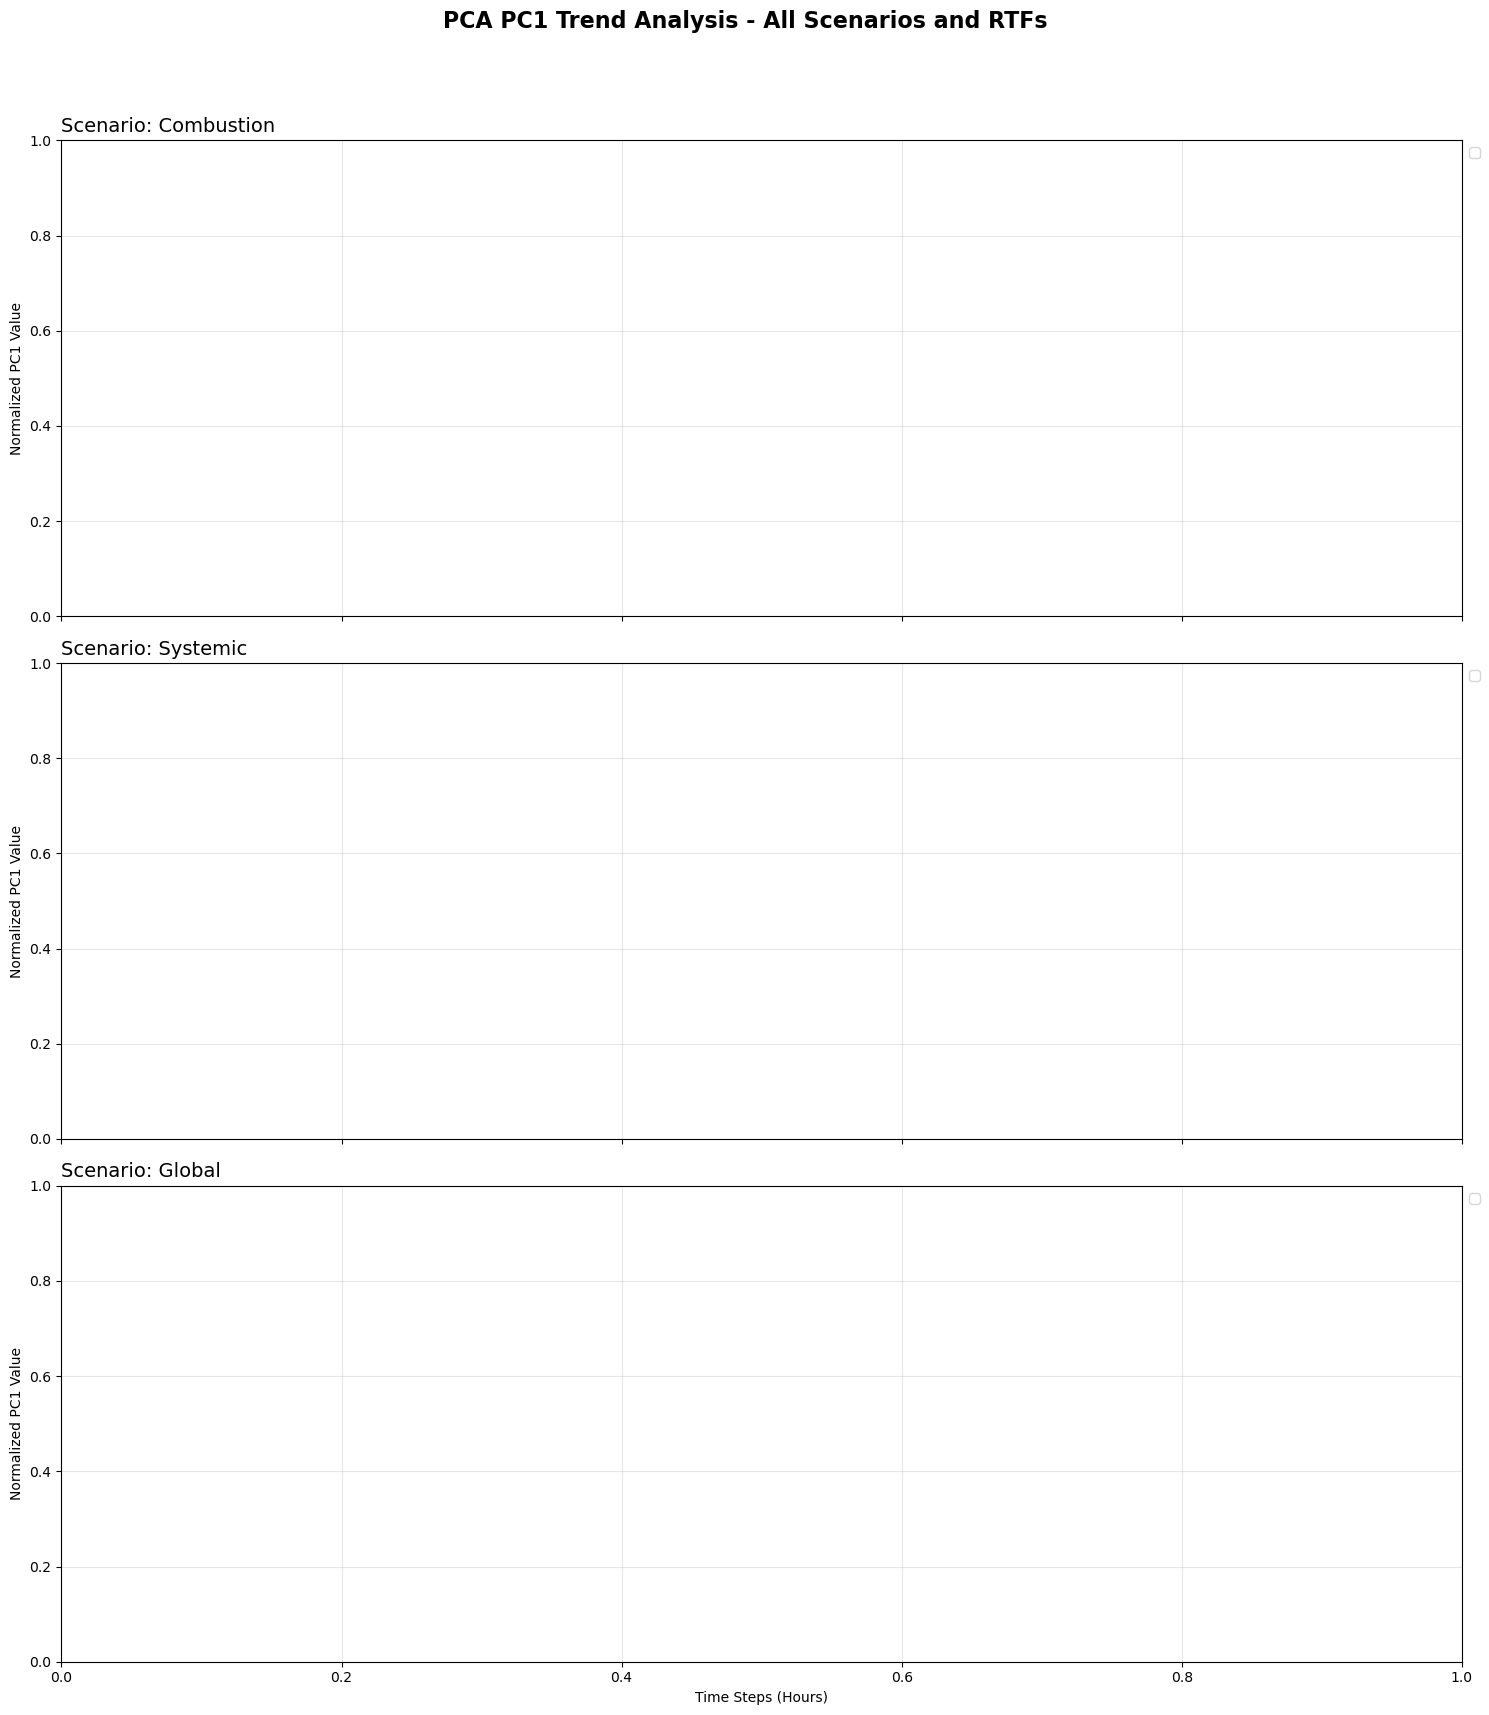

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_all_scenarios(file_list):
    scenarios = ['Combustion', 'Systemic', 'Global']
    colors = ['#1f77b4', '#ff7f0e', "#1aab1a", '#d62728', '#9467bd']

    fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
    fig.suptitle('PCA PC1 Trend Analysis - All Scenarios and RTFs', fontsize=16, fontweight='bold')

    for i, scenario in enumerate(scenarios):
        column_name = f"PC1_{scenario}"
        ax = axes[i]

        for idx, file_path in enumerate(file_list):
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                rtf_label = file_path.replace('PCA_Results_', '').replace('.csv', '')
                ax.plot(df[column_name], label=rtf_label, color=colors[idx % len(colors)], alpha=0.8)

        ax.set_title(f'Scenario: {scenario}', fontsize=14, loc='left')
        ax.set_ylabel('Normalized PC1 Value')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.xlabel('Time Steps (Hours)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('All_Scenarios_Comparison.png', dpi=300)
    plt.show()

output_files = [f"PCA_Results_run_to_failure{i}.csv" for i in range(1, 8)]
plot_all_scenarios(output_files)


<>:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\LOQ\AppData\Local\Temp\ipykernel_24368\3159373942.py:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  VAL_FILE = 'Plot Data\Dirty Data\PCA_Results_run_to_failure7.csv'


--- Loading Best Model from BiLSTM_Global_best.pt ---
--- Creating Collapsed Model (Simulating Trial 123) ---
Simulating RUL...
PoC Result saved as 'PoC_RUL_Verification.png'


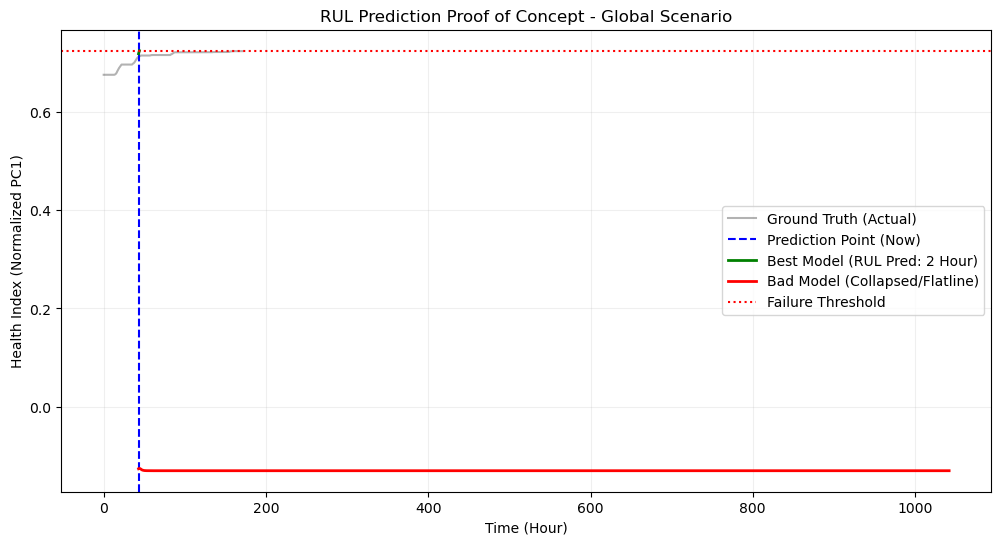

In [ ]:
import torch
import pandas as pd
from model_train import BiLSTM
import numpy as np
import matplotlib.pyplot as plt

VARIATION = 'Global'
BEST_MODEL_PATH = f"BiLSTM_{VARIATION}_best.pt"
VAL_FILE = 'Plot Data\\Dirty Data\\PCA_Results_run_to_failure7.csv'
BEST_PARAMS = {'hidden_dim': 32, 'window_size': 36}
BAD_PARAMS = {'hidden_dim': 32, 'window_size': 14, 'lr': 0.0014517193218636021}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def create_bad_model():
    print("--- Creating Collapsed Model (Simulating Trial 123) ---")
    model = BiLSTM(1, BAD_PARAMS['hidden_dim'], 1).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=BAD_PARAMS['lr'])
    criterion = torch.nn.MSELoss()
    x_dummy = torch.randn(10, BAD_PARAMS['window_size'], 1).to(DEVICE)
    y_dummy = torch.randn(10, 1).to(DEVICE)

    for _ in range(5):
        optimizer.zero_grad()
        loss = criterion(model(x_dummy), y_dummy)
        loss.backward()
        optimizer.step()
    return model

def rollout(model, seed_seq, threshold, max_steps=1000):
    model.eval()
    seq = seed_seq.clone().detach().to(DEVICE)
    preds = []

    for _ in range(max_steps):
        with torch.no_grad():
            out = model(seq.unsqueeze(0)).item()
        preds.append(out)
        new_val = torch.tensor([[out]], device=DEVICE)
        seq = torch.cat([seq[1:], new_val], dim=0)
        if out >= threshold:
            break
    return preds

def run_proof_of_concept():
    df = pd.read_csv(VAL_FILE)
    series = df[f"PC1_{VARIATION}"].values.astype(np.float32)
    threshold = series[-1]
    split_idx = int(len(series) * 0.25)
    seed_data = series[split_idx - BEST_PARAMS['window_size']: split_idx]
    seed_tensor = torch.from_numpy(seed_data).unsqueeze(-1)

    print(f"--- Loading Best Model from {BEST_MODEL_PATH} ---")
    best_model = BiLSTM(1, BEST_PARAMS['hidden_dim'], 1).to(DEVICE)
    best_model.load_state_dict(torch.load(BEST_MODEL_PATH))

    bad_model = create_bad_model()
    print("Simulating RUL...")
    preds_best = rollout(best_model, seed_tensor, threshold)
    preds_bad = rollout(bad_model, seed_tensor, threshold)

    plt.figure(figsize=(12, 6))
    plt.plot(range(len(series)), series, color='black', label='Ground Truth (Actual)', alpha=0.3)
    plt.axvline(x=split_idx, color='blue', linestyle='--', label='Prediction Point (Now)')
    time_best = range(split_idx, split_idx + len(preds_best))
    plt.plot(time_best, preds_best, color='green', linewidth=2, label=f'Best Model (RUL Pred: {len(preds_best)} Hour)')
    time_bad = range(split_idx, split_idx + len(preds_bad))
    plt.plot(time_bad, preds_bad, color='red', linewidth=2, label='Bad Model (Collapsed/Flatline)')
    plt.axhline(y=threshold, color='red', linestyle=':', label='Failure Threshold')
    plt.title(f'RUL Prediction Proof of Concept - {VARIATION} Scenario')
    plt.xlabel('Time (Hour)')
    plt.ylabel('Health Index (Normalized PC1)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig('PoC_RUL_Verification.png', dpi=300)
    print("PoC Result saved as 'PoC_RUL_Verification.png'")
    plt.show()

if __name__ == "__main__":
    run_proof_of_concept()


--- Loading Model: BiLSTM_Global_best.pt ---
--- Simulating RUL for Residual Analysis ---

[HASIL STATISTIK]
Mean Residual: -49.00 Jam
Std Deviation: 42.78
Shapiro-Wilk: Stat=0.9662, p-value=0.8659


C:\Users\LOQ\AppData\Local\Temp\ipykernel_24660\2309554168.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Phase', y='Error', data=pd.DataFrame(plot_df), ax=ax3, palette='Set2')



--- Analisis Selesai! Grafik disimpan di: Final_Proof_of_Concept_Normality.png ---


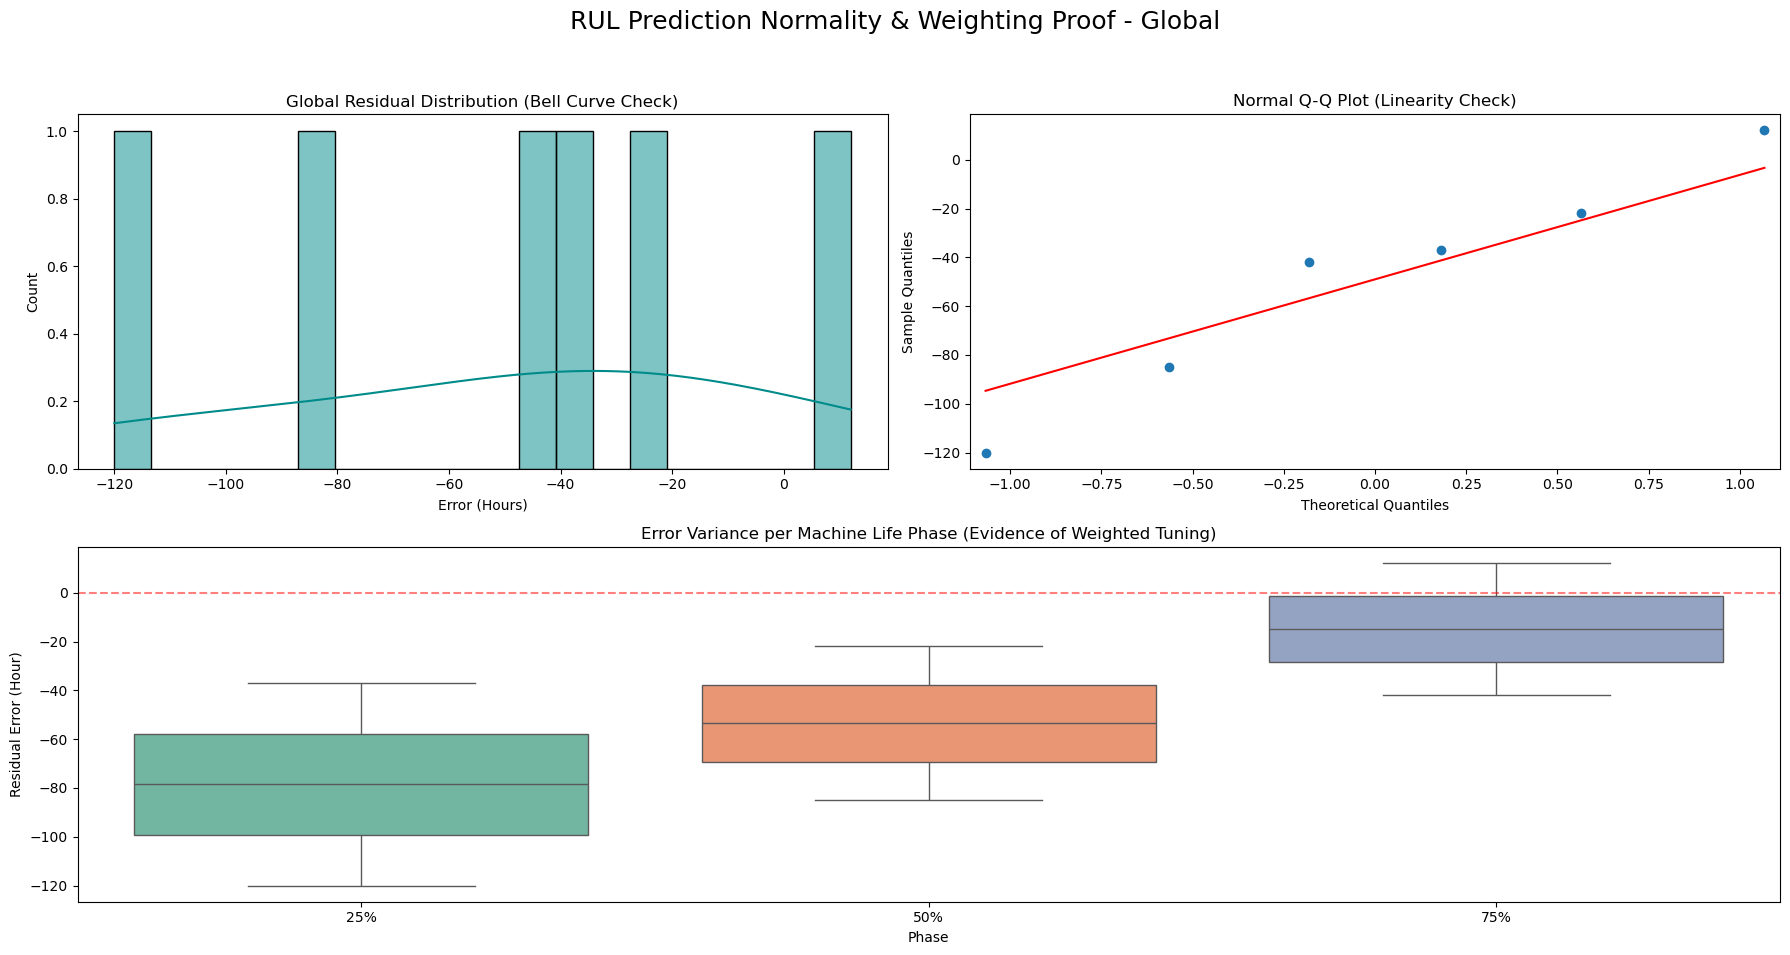

In [ ]:
import torch
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from model_train import BiLSTM
import os
import matplotlib.pyplot as plt

# Memastikan arsitektur BiLSTM terbaca
# =========================================================
# 1. PARAMETER - SESUAIKAN DENGAN HASIL TUNING ANDA
# =========================================================
CONFIG = {
    "variation": "Global",
    "model_path": "BiLSTM_Global_best.pt",
    "val_files": [
        "PCA_Results_run_to_failure6.csv",
        "PCA_Results_run_to_failure7.csv" 
    ],
    "window_size": 17,  # Ganti dengan best window_size Anda
    "hidden_dim": 24,   # Ganti dengan best hidden_dim Anda
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

# =========================================================
# 2. FUNGSI ROLLOUT (SIMULASI PREDIKSI)
# =========================================================
def simulate_rul(model, seed_seq, threshold, device, max_steps=2000):
    model.eval()
    current_seq = seed_seq.clone().detach().to(device)
    steps_predicted = 0
    
    while steps_predicted < max_steps:
        with torch.no_grad():
            # Input shape: (1, window_size, 1)
            prediction = model(current_seq.unsqueeze(0)).item()
        
        # Update Sliding Window
        new_entry = torch.tensor([[prediction]], device=device)
        current_seq = torch.cat([current_seq[1:], new_entry], dim=0)
        
        steps_predicted += 1
        if prediction >= threshold:
            break
            
    return steps_predicted

# =========================================================
# 3. MAIN ANALYSIS SCRIPT
# =========================================================
def run_full_normality_test():
    # A. Validasi keberadaan file
    if not os.path.exists(CONFIG["model_path"]):
        print(f"Error: Model '{CONFIG['model_path']}' tidak ditemukan!")
        return

    # B. Load Model
    print(f"--- Loading Model: {CONFIG['model_path']} ---")
    model = BiLSTM(1, CONFIG["hidden_dim"], 1).to(CONFIG["device"])
    model.load_state_dict(torch.load(CONFIG["model_path"], map_location=CONFIG["device"]))
    model.eval()

    residuals_data = {"25%": [], "50%": [], "75%": []}
    target_col = f"PC1_{CONFIG['variation']}"

    # C. Loop Data Validasi
    print("--- Simulating RUL for Residual Analysis ---")
    for file_name in CONFIG["val_files"]:
        if not os.path.exists(file_name):
            print(f"Warning: File {file_name} tidak ditemukan, skipping...")
            continue
            
        df = pd.read_csv(file_name)
        series = df[target_col].values.astype(np.float32)
        total_length = len(series)
        fail_threshold = series[-1]

        for label, pct in [("25%", 0.25), ("50%", 0.50), ("75%", 0.75)]:
            idx = int(total_length * pct)
            if idx < CONFIG["window_size"]: idx = CONFIG["window_size"]
            
            # Ambil sejarah (seed)
            seed = series[idx - CONFIG["window_size"] : idx]
            seed_tensor = torch.from_numpy(seed).unsqueeze(-1)
            
            true_rul = total_length - idx
            pred_rul = simulate_rul(model, seed_tensor, fail_threshold, CONFIG["device"])
            
            # Hitung Residual (Prediksi - Aktual)
            res = pred_rul - true_rul
            residuals_data[label].append(res)

    # D. Flatten Data untuk Uji Global
    all_res = []
    for k in residuals_data: all_res.extend(residuals_data[k])
    
    if not all_res:
        print("Error: Tidak ada data residual yang berhasil dihitung.")
        return

    # E. Statistik Deskriptif & Shapiro-Wilk
    stat, p_val = stats.shapiro(all_res)
    print(f"\n[HASIL STATISTIK]")
    print(f"Mean Residual: {np.mean(all_res):.2f} Jam")
    print(f"Std Deviation: {np.std(all_res):.2f}")
    print(f"Shapiro-Wilk: Stat={stat:.4f}, p-value={p_val:.4f}")
    
    # F. Visualisasi Terpadu
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Distribution & KDE
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(all_res, kde=True, ax=ax1, color='darkcyan', bins=20)
    ax1.set_title('Global Residual Distribution (Bell Curve Check)')
    ax1.set_xlabel('Error (Hours)')

    # 2. Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    qqplot(np.array(all_res), line='s', ax=ax2)
    ax2.set_title('Normal Q-Q Plot (Linearity Check)')

    # 3. Comparison per Phase (BOXPLOT)
    ax3 = fig.add_subplot(gs[1, :])
    plot_df = []
    for phase, values in residuals_data.items():
        for v in values:
            plot_df.append({"Phase": phase, "Error": v})
    
    sns.boxplot(x='Phase', y='Error', data=pd.DataFrame(plot_df), ax=ax3, palette='Set2')
    ax3.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax3.set_title('Error Variance per Machine Life Phase (Evidence of Weighted Tuning)')
    ax3.set_ylabel('Residual Error (Hour)')

    plt.suptitle(f'RUL Prediction Normality & Weighting Proof - {CONFIG["variations"]}', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    output_plot = "Final_Proof_of_Concept_Normality.png"
    plt.savefig(output_plot, dpi=300)
    print(f"\n--- Analisis Selesai! Grafik disimpan di: {output_plot} ---")
    plt.show()

if __name__ == "__main__":
    run_full_normality_test()